# 03 Build matched canine analysis matrix

Purpose: merge GSE238110 log2-CPM expression with matched DOG2 clinical metadata and create analysis-ready matrices.

In [1]:
from pathlib import Path
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

print("Project root:", PROJECT_ROOT)
print("Raw data dir:", RAW_DIR)
print("Processed data dir:", PROCESSED_DIR)

Project root: C:\Users\olegk\Desktop\paper4_sarcoma_dog
Raw data dir: C:\Users\olegk\Desktop\paper4_sarcoma_dog\data\raw
Processed data dir: C:\Users\olegk\Desktop\paper4_sarcoma_dog\data\processed


In [2]:
expr_path = PROCESSED_DIR / "GSE238110_log2cpm_detection20.csv"
clinical_path = PROCESSED_DIR / "DOG2_clinical_matched_to_GSE238110.csv"

expr = pd.read_csv(expr_path, index_col=0)
clinical = pd.read_csv(clinical_path)

print("Expression shape genes x samples:", expr.shape)
print("Clinical shape:", clinical.shape)
display(expr.iloc[:5, :5])
display(clinical.head())

Expression shape genes x samples: (21016, 198)
Clinical shape: (186, 26)


,14_0614__Tumor,5_0220__Tumor,13_0613__Tumor,26_0722__Tumor,4_0214__Tumor
gene_id,,,,,
A1BG_3,0.000000,0.084511,0.000000,0.000000,0.512624
A2ML1_3,0.073920,0.000000,0.000000,0.077877,0.449634
A3GALT2_3,1.795312,0.084511,0.000000,0.353118,0.000000
A4GALT_3,4.185168,0.835335,1.738246,2.254452,1.590395
A4GNT_3,0.000000,0.000000,0.136738,0.000000,0.000000


,Patient ID,Tumor Location,Site,age,weight,breed,gender,PH,ALP,Group,DFS_time,DFS_status,OS_time,OS_status,treatment,primary_immune_subtype,patient_id_clean,original_sample_column,sample_id_bracket,sample_type,dfi_time,dfi_event,os_time,os_event,dfi_event_365d,dfi_event_540d
0,514,Left distal radius,UW,5.5,42.7,Mixed Breed,Spayed Female,0,Normal,NPHNALP,33,0,117,1,SOC,ID,514,100_0514_tumor,100_0514_tumor,primary_or_tumor,33,0,117,1,NaN,NaN
1,518,Left proximal humerus,UW,8.3,44.3,Rottweiler,Spayed Female,1,Elevated,PHEALP,12,0,248,0,SOC,IE-ECM,518,101_0518_tumor,101_0518_tumor,primary_or_tumor,12,0,248,0,NaN,NaN
2,619,Left distal tibia,OSU,7.5,30.8,Mixed Breed,Spayed Female,0,Normal,NPHNALP,63,1,622,0,SOC,IE-ECM,619,102_0619_tumor,102_0619_tumor,primary_or_tumor,63,1,622,0,1.0,1.0
3,639,Left distal femur,OSU,6.9,36.2,Greyhound,Castrated Male,0,Normal,NPHNALP,234,1,283,1,SOC,ID,639,103_0639_tumor,103_0639_tumor,primary_or_tumor,234,1,283,1,1.0,1.0
4,702,Right distal ulna,UIL,9.5,33.2,Labrador Retriever,Castrated Male,0,Normal,NPHNALP,153,1,171,0,SOC,IE-ECM,702,104_0702_tumor,104_0702_tumor,primary_or_tumor,153,1,171,0,1.0,1.0


In [3]:
sample_col = "original_sample_column"
available_samples = [s for s in clinical[sample_col].astype(str) if s in expr.columns]

expr_matched = expr[available_samples].T
expr_matched.index.name = "sample_id"
clinical_matched = clinical.set_index(sample_col).loc[available_samples].copy()

print("Matched expression shape samples x genes:", expr_matched.shape)
print("Matched clinical shape:", clinical_matched.shape)
display(expr_matched.iloc[:5, :5])
display(clinical_matched.head())

Matched expression shape samples x genes: (186, 21016)
Matched clinical shape: (186, 25)


gene_id,A1BG_3,A2ML1_3,A3GALT2_3,A4GALT_3,A4GNT_3
sample_id,,,,,
100_0514_tumor,0.127814,0.127814,0.454751,2.563093,0.000000
101_0518_tumor,0.000000,0.000000,0.322564,3.324786,0.170278
102_0619_tumor,0.000000,0.241690,0.241690,2.829771,0.448640
103_0639_tumor,0.574338,0.000000,0.315563,2.400183,0.000000
104_0702_tumor,0.000000,0.000000,0.000000,3.064320,0.000000


,Patient ID,Tumor Location,Site,age,weight,breed,gender,PH,ALP,Group,DFS_time,DFS_status,OS_time,OS_status,treatment,primary_immune_subtype,patient_id_clean,sample_id_bracket,sample_type,dfi_time,dfi_event,os_time,os_event,dfi_event_365d,dfi_event_540d
original_sample_column,,,,,,,,,,,,,,,,,,,,,,,,,
100_0514_tumor,514,Left distal radius,UW,5.5,42.7,Mixed Breed,Spayed Female,0,Normal,NPHNALP,33,0,117,1,SOC,ID,514,100_0514_tumor,primary_or_tumor,33,0,117,1,NaN,NaN
101_0518_tumor,518,Left proximal humerus,UW,8.3,44.3,Rottweiler,Spayed Female,1,Elevated,PHEALP,12,0,248,0,SOC,IE-ECM,518,101_0518_tumor,primary_or_tumor,12,0,248,0,NaN,NaN
102_0619_tumor,619,Left distal tibia,OSU,7.5,30.8,Mixed Breed,Spayed Female,0,Normal,NPHNALP,63,1,622,0,SOC,IE-ECM,619,102_0619_tumor,primary_or_tumor,63,1,622,0,1.0,1.0
103_0639_tumor,639,Left distal femur,OSU,6.9,36.2,Greyhound,Castrated Male,0,Normal,NPHNALP,234,1,283,1,SOC,ID,639,103_0639_tumor,primary_or_tumor,234,1,283,1,1.0,1.0
104_0702_tumor,702,Right distal ulna,UIL,9.5,33.2,Labrador Retriever,Castrated Male,0,Normal,NPHNALP,153,1,171,0,SOC,IE-ECM,702,104_0702_tumor,primary_or_tumor,153,1,171,0,1.0,1.0


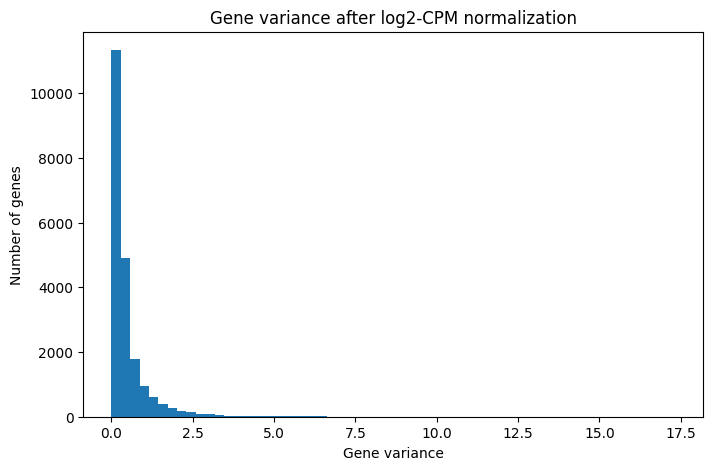

Top variable matrix shape: (186, 5000)


In [4]:
gene_variance = expr_matched.var(axis=0).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.hist(gene_variance, bins=60)
plt.xlabel("Gene variance")
plt.ylabel("Number of genes")
plt.title("Gene variance after log2-CPM normalization")
plt.show()

top_n = 5000
top_variable_genes = gene_variance.head(top_n).index.tolist()
expr_top = expr_matched[top_variable_genes].copy()

print("Top variable matrix shape:", expr_top.shape)

In [5]:
for top_n in [10000, 5000, 2000]:
    selected_genes = gene_variance.head(top_n).index.tolist()
    expr_top = expr_matched[selected_genes].copy()
    expr_top.to_csv(
        PROCESSED_DIR / f"GSE238110_DOG2_expression_log2cpm_matched_top{top_n}var.csv"
    )
    analysis = clinical_matched.join(expr_top, how="inner")
    analysis.to_csv(
        PROCESSED_DIR / f"GSE238110_DOG2_analysis_top{top_n}var.csv"
    )
    print(top_n, analysis.shape)


10000 (186, 10025)
5000 (186, 5025)
2000 (186, 2025)


In [6]:
endpoint_summary = []
for col in ["metastasis_event", "os_time", "os_event", "dfi_time", "dfi_event"]:
    if col in clinical_matched.columns:
        endpoint_summary.append({
            "column": col,
            "non_missing": int(clinical_matched[col].notna().sum()),
            "unique_values": int(clinical_matched[col].nunique(dropna=True))
        })

display(pd.DataFrame(endpoint_summary))

,column,non_missing,unique_values
0,os_time,186,163
1,os_event,186,2
2,dfi_time,186,136
3,dfi_event,186,2


In [7]:
analysis = clinical_matched.join(expr_top, how="inner")
analysis.to_csv(PROCESSED_DIR / "GSE238110_DOG2_analysis_top5000var.csv")

expr_matched.to_csv(PROCESSED_DIR / "GSE238110_DOG2_expression_log2cpm_matched_allgenes.csv")
expr_top.to_csv(PROCESSED_DIR / "GSE238110_DOG2_expression_log2cpm_matched_top5000var.csv")

print("Saved analysis files:")
print(PROCESSED_DIR / "GSE238110_DOG2_analysis_top5000var.csv")
print(PROCESSED_DIR / "GSE238110_DOG2_expression_log2cpm_matched_allgenes.csv")
print(PROCESSED_DIR / "GSE238110_DOG2_expression_log2cpm_matched_top5000var.csv")

Saved analysis files:
C:\Users\olegk\Desktop\paper4_sarcoma_dog\data\processed\GSE238110_DOG2_analysis_top5000var.csv
C:\Users\olegk\Desktop\paper4_sarcoma_dog\data\processed\GSE238110_DOG2_expression_log2cpm_matched_allgenes.csv
C:\Users\olegk\Desktop\paper4_sarcoma_dog\data\processed\GSE238110_DOG2_expression_log2cpm_matched_top5000var.csv
